# Laboratorio 4 - Análisis de datos geoespaciales

**Entrega completa: ejercicios 1 al 8**  
**Integrantes:** Milton Polanco y Osman de León

En este laboratorio se obtienen imágenes Sentinel-2 de los lagos Atitlán y Amatitlán, se calculan los índices solicitados (NDVI, NDWI y un indicador de cianobacteria basado en clorofila-a) y se analiza su comportamiento en el tiempo y en el espacio.

## Configuración

Las coordenadas, fechas, nubosidad y satélite se copiaron de la consigna. Se trabaja a 20 m porque la banda B05, usada en el cálculo de cianobacteria, tiene esa resolución.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import json
import sys


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src.rasters import leer_bandas

CARPETA_RAW = RAIZ / "data" / "raw"
CARPETA_PROCESSED = RAIZ / "data" / "processed"
CARPETA_FIGURES = RAIZ / "figures"
for carpeta in (CARPETA_RAW, CARPETA_PROCESSED, CARPETA_FIGURES):
    carpeta.mkdir(parents=True, exist_ok=True)

ARCHIVO_RESUMEN = CARPETA_PROCESSED / "resumen_temporal.csv"
ARCHIVO_CRITICAS = CARPETA_PROCESSED / "fechas_criticas.csv"
ARCHIVO_CATALOGO = CARPETA_RAW / "catalogo_escenas.json"
ARCHIVO_FIGURA = CARPETA_FIGURES / "evolucion_temporal_cianobacteria.png"

URL_OPENEO = "https://openeosh.dataspace.copernicus.eu"
URL_STAC = "https://earth-search.aws.element84.com/v1/search"
COLECCION_STAC = "sentinel-2-l2a"

LAGOS = {
    "Amatitlán": {
        "west": -90.638065,
        "east": -90.512924,
        "south": 14.412347,
        "north": 14.493799,
    },
    "Atitlán": {
        "west": -91.326256,
        "east": -91.071510,
        "south": 14.594800,
        "north": 14.750979,
    },
}

FECHAS = pd.DataFrame([
    ("Amatitlán", "2025-01-28", 0.06, "Sentinel-2B"),
    ("Amatitlán", "2025-04-15", 0.09, "Sentinel-2A"),
    ("Amatitlán", "2025-04-28", 1.03, "Sentinel-2B"),
    ("Amatitlán", "2025-11-24", 0.50, "Sentinel-2B"),
    ("Amatitlán", "2026-01-08", 0.77, "Sentinel-2C"),
    ("Amatitlán", "2026-02-02", 0.39, "Sentinel-2B"),
    ("Amatitlán", "2026-02-07", 0.02, "Sentinel-2C"),
    ("Amatitlán", "2026-03-29", 0.01, "Sentinel-2C"),
    ("Amatitlán", "2026-04-13", 0.09, "Sentinel-2B"),
    ("Amatitlán", "2026-04-28", 4.96, "Sentinel-2C"),
    ("Amatitlán", "2026-06-19", 13.00, "Sentinel-2A"),
    ("Atitlán", "2025-01-18", 0.02, "Sentinel-2B"),
    ("Atitlán", "2025-04-13", 0.54, "Sentinel-2C"),
    ("Atitlán", "2025-05-13", 4.37, "Sentinel-2C"),
    ("Atitlán", "2025-07-17", 3.57, "Sentinel-2A"),
    ("Atitlán", "2025-11-21", 3.15, "Sentinel-2A"),
    ("Atitlán", "2025-12-29", 3.17, "Sentinel-2C"),
    ("Atitlán", "2026-02-12", 0.04, "Sentinel-2B"),
    ("Atitlán", "2026-03-24", 3.17, "Sentinel-2B"),
    ("Atitlán", "2026-04-13", 0.01, "Sentinel-2B"),
    ("Atitlán", "2026-04-28", 4.96, "Sentinel-2C"),
    ("Atitlán", "2026-07-22", 4.02, "Sentinel-2B"),
], columns=["lago", "fecha", "nubosidad_oficial_pct", "satelite"])

FECHAS["fecha"] = pd.to_datetime(FECHAS["fecha"])
pd.set_option("display.max_columns", 20)

# 1. Conexión con la API de Sentinel-2

Se consulta la API openEO de Copernicus Data Space para comprobar que la colección `SENTINEL2_L2A` y las bandas necesarias están disponibles. Esta consulta de metadatos no requiere iniciar sesión.

In [2]:
versiones = requests.get(f"{URL_OPENEO}/.well-known/openeo", timeout=30)
versiones.raise_for_status()
url_api = versiones.json()["versions"][-1]["url"].rstrip("/")

respuesta_coleccion = requests.get(
    f"{url_api}/collections/SENTINEL2_L2A", timeout=30
)
respuesta_coleccion.raise_for_status()
metadatos_coleccion = respuesta_coleccion.json()
bandas_disponibles = metadatos_coleccion["cube:dimensions"]["bands"]["values"]
bandas_necesarias = ["B02", "B03", "B04", "B05", "B08", "B11", "B12"]

pd.Series({
    "api": "Copernicus Data Space openEO",
    "coleccion": metadatos_coleccion["id"],
    "bandas disponibles": all(b in bandas_disponibles for b in bandas_necesarias),
})

api                   Copernicus Data Space openEO
coleccion                            SENTINEL2_L2A
bandas disponibles                            True
dtype: object

La respuesta confirma que la colección puede usarse. El procesamiento directo en openEO pide autenticación OIDC, así que las imágenes se leen desde el catálogo público STAC de Earth Search, que distribuye el mismo producto Sentinel-2 L2A como COG. No se guardan credenciales en el proyecto.

# 2. Obtención de los datos raster

Cada fecha se busca por separado. De cada archivo se lee solo el rectángulo del lago y, cuando el área cruza dos teselas, se completa el mosaico con ambas. Las escenas completas no se guardan en el repositorio.

In [3]:
def buscar_escenas(bbox, fecha, nubosidad, satelite):
    respuesta = requests.post(
        URL_STAC,
        json={
            "collections": [COLECCION_STAC],
            "bbox": [bbox["west"], bbox["south"], bbox["east"], bbox["north"]],
            "datetime": f"{fecha}T00:00:00Z/{fecha}T23:59:59Z",
            "limit": 20,
        },
        timeout=45,
    )
    respuesta.raise_for_status()

    escenas = [
        escena for escena in respuesta.json().get("features", [])
        if escena["properties"].get("platform", "").lower() == satelite.lower()
    ]
    if not escenas:
        raise LookupError(f"No se encontró {satelite} para {fecha}.")

    # La nubosidad de la consigna ayuda a ordenar las teselas del mismo día.
    escenas.sort(key=lambda escena: abs(
        float(escena["properties"].get("eo:cloud_cover", 100)) - nubosidad
    ))
    return escenas

In [4]:
FECHAS

,lago,fecha,nubosidad_oficial_pct,satelite
0,Amatitlán,2025-01-28,0.06,Sentinel-2B
1,Amatitlán,2025-04-15,0.09,Sentinel-2A
2,Amatitlán,2025-04-28,1.03,Sentinel-2B
3,Amatitlán,2025-11-24,0.50,Sentinel-2B
4,Amatitlán,2026-01-08,0.77,Sentinel-2C
5,Amatitlán,2026-02-02,0.39,Sentinel-2B
6,Amatitlán,2026-02-07,0.02,Sentinel-2C
7,Amatitlán,2026-03-29,0.01,Sentinel-2C
8,Amatitlán,2026-04-13,0.09,Sentinel-2B
9,Amatitlán,2026-04-28,4.96,Sentinel-2C


# 3. Cálculo de NDVI, NDWI y cianobacteria

Se usaron las siguientes expresiones:

- $NDVI=(B08-B04)/(B08+B04)$
- $NDWI=(B03-B08)/(B03+B08)$
- $NDCI=(B05-B04)/(B05+B04)$

El valor de clorofila-a se obtiene con el polinomio del script **CyanoLakes Chlorophyll-a NDCI** de Sentinel Hub: $826.57NDCI^3-176.43NDCI^2+19NDCI+4.071$. También se reproduce su máscara de agua y se usa la banda SCL para excluir nubes, sombras y píxeles sin datos.

In [5]:
def division_segura(numerador, denominador):
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.divide(
            numerador,
            denominador,
            out=np.full_like(numerador, np.nan, dtype="float32"),
            where=np.abs(denominador) > 1e-8,
        )


def calcular_indices(bandas):
    azul = bandas["B02"]
    verde = bandas["B03"]
    rojo = bandas["B04"]
    borde_rojo = bandas["B05"]
    nir = bandas["B08"]
    swir1 = bandas["B11"]
    swir2 = bandas["B12"]
    scl = bandas["SCL"].astype("int16")

    ndvi = division_segura(nir - rojo, nir + rojo)
    ndwi = division_segura(verde - nir, verde + nir)
    mndwi = division_segura(verde - swir1, verde + swir1)
    ndwi_hojas = division_segura(nir - swir1, nir + swir1)
    awei_sombra = azul + 2.5 * verde - 1.5 * (nir + swir1) - 0.25 * swir2
    awei_sin_sombra = 4 * (verde - swir1) - (0.25 * nir + 2.75 * swir1)
    dbsi = division_segura(swir1 - verde, swir1 + verde) - ndvi

    agua = (
        (mndwi > 0.42)
        | (ndwi > 0.40)
        | (awei_sin_sombra > 0.1879)
        | (awei_sombra > 0.1112)
        | (ndvi < -0.20)
        | (ndwi_hojas > 1)
    )
    agua &= ~((awei_sin_sombra <= -0.03) | (dbsi > 0))

    # SCL: 3 es sombra; 8, 9 y 10 son nubes; 11 es nieve o hielo.
    cielo_valido = ~np.isin(scl, [0, 3, 8, 9, 10, 11])
    datos_disponibles = np.all(
        np.stack([bandas[nombre] > 0 for nombre in bandas if nombre != "SCL"]),
        axis=0,
    )
    pixeles_validos = agua & cielo_valido & datos_disponibles

    ndci = division_segura(borde_rojo - rojo, borde_rojo + rojo)
    cianobacteria = 826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071
    rango_valido = pixeles_validos & (cianobacteria >= 0) & (cianobacteria <= 500)

    return {
        "ndvi": np.where(pixeles_validos, ndvi, np.nan),
        "ndwi": np.where(pixeles_validos, ndwi, np.nan),
        "cianobacteria": np.where(rango_valido, cianobacteria, np.nan),
        "pixeles_validos": pixeles_validos,
        "datos_disponibles": datos_disponibles,
    }

In [6]:
def promedio_valido(arreglo):
    valores = arreglo[np.isfinite(arreglo)]
    return float(valores.mean()) if valores.size else np.nan


def procesar_observacion(fila):
    lago = fila["lago"]
    fecha = fila["fecha"].strftime("%Y-%m-%d")
    bbox = LAGOS[lago]
    escenas = buscar_escenas(
        bbox, fecha, fila["nubosidad_oficial_pct"], fila["satelite"]
    )
    bandas = leer_bandas(escenas, bbox)
    indices = calcular_indices(bandas)
    principal = escenas[0]

    disponibles = int(indices["datos_disponibles"].sum())
    total = indices["datos_disponibles"].size
    resultado = {
        "lago": lago,
        "fecha": fecha,
        "satelite": fila["satelite"],
        "nubosidad_oficial_pct": fila["nubosidad_oficial_pct"],
        "nubosidad_catalogo_pct": principal["properties"].get("eo:cloud_cover", np.nan),
        "cobertura_bbox_pct": 100 * disponibles / total,
        "pixeles_agua_validos": int(indices["pixeles_validos"].sum()),
        "cianobacteria_promedio": promedio_valido(indices["cianobacteria"]),
        "ndvi_promedio": promedio_valido(indices["ndvi"]),
        "ndwi_promedio": promedio_valido(indices["ndwi"]),
        "item_principal": principal["id"],
    }

    registro = {
        "lake": lago,
        "date": fecha,
        "official_cloud_cover": fila["nubosidad_oficial_pct"],
        "satellite": fila["satelite"],
        "items": [
            {
                "id": escena["id"],
                "datetime": escena["properties"].get("datetime"),
                "cloud_cover": escena["properties"].get("eo:cloud_cover"),
            }
            for escena in escenas
        ],
    }
    return resultado, registro

In [7]:
VOLVER_A_DESCARGAR = False

if ARCHIVO_RESUMEN.exists() and not VOLVER_A_DESCARGAR:
    resumen = pd.read_csv(ARCHIVO_RESUMEN, parse_dates=["fecha"])
    print("Se usó el resumen guardado. Cambie VOLVER_A_DESCARGAR a True para repetir la consulta.")
else:
    resultados = []
    catalogo = []

    for numero, fila in FECHAS.iterrows():
        fecha_texto = fila["fecha"].strftime("%Y-%m-%d")
        print(f"[{numero + 1:02d}/{len(FECHAS)}] {fila['lago']} - {fecha_texto}")

        try:
            resultado, registro = procesar_observacion(fila)
        except LookupError as error:
            print(f"  Aviso: {error}")
            resultado = {
                "lago": fila["lago"],
                "fecha": fecha_texto,
                "satelite": fila["satelite"],
                "nubosidad_oficial_pct": fila["nubosidad_oficial_pct"],
                "nubosidad_catalogo_pct": np.nan,
                "cobertura_bbox_pct": 0.0,
                "pixeles_agua_validos": 0,
                "cianobacteria_promedio": np.nan,
                "ndvi_promedio": np.nan,
                "ndwi_promedio": np.nan,
                "item_principal": "SIN_ESCENA_EN_CATALOGO",
            }
            registro = {
                "lake": fila["lago"],
                "date": fecha_texto,
                "satellite": fila["satelite"],
                "items": [],
                "warning": str(error),
            }

        resultados.append(resultado)
        catalogo.append(registro)

    resumen = pd.DataFrame(resultados)
    resumen["fecha"] = pd.to_datetime(resumen["fecha"])
    resumen = resumen.sort_values(["lago", "fecha"]).reset_index(drop=True)
    resumen.to_csv(ARCHIVO_RESUMEN, index=False, encoding="utf-8-sig")

    contenido_catalogo = {
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "source": URL_STAC,
        "collection": COLECCION_STAC,
        "records": catalogo,
    }
    ARCHIVO_CATALOGO.write_text(
        json.dumps(contenido_catalogo, indent=2, ensure_ascii=False),
        encoding="utf-8",
    )

Se usó el resumen guardado. Cambie VOLVER_A_DESCARGAR a True para repetir la consulta.


In [8]:
columnas = [
    "lago", "fecha", "satelite", "nubosidad_oficial_pct",
    "cobertura_bbox_pct", "pixeles_agua_validos",
    "cianobacteria_promedio", "ndvi_promedio", "ndwi_promedio",
]
resumen[columnas].round(3)

C:\Users\Emadlg\AppData\Local\Temp\ipykernel_27276\1319194963.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  resumen[columnas].round(3)


,lago,fecha,satelite,nubosidad_oficial_pct,cobertura_bbox_pct,pixeles_agua_validos,cianobacteria_promedio,ndvi_promedio,ndwi_promedio
0,Amatitlán,2025-01-28,Sentinel-2B,0.06,99.999,27596,14.355,-0.347,0.586
1,Amatitlán,2025-04-15,Sentinel-2A,0.09,100.000,11583,10.343,-0.111,0.335
2,Amatitlán,2025-04-28,Sentinel-2B,1.03,100.000,22780,13.521,-0.085,0.333
3,Amatitlán,2025-11-24,Sentinel-2B,0.50,100.000,29854,13.181,-0.351,0.513
4,Amatitlán,2026-01-08,Sentinel-2C,0.77,100.000,30925,23.067,-0.087,0.365
5,Amatitlán,2026-02-02,Sentinel-2B,0.39,100.000,2611,6.490,-0.205,0.356
6,Amatitlán,2026-02-07,Sentinel-2C,0.02,100.000,9064,7.837,-0.220,0.433
7,Amatitlán,2026-03-29,Sentinel-2C,0.01,100.000,22171,17.150,-0.063,0.320
8,Amatitlán,2026-04-13,Sentinel-2B,0.09,100.000,34280,16.418,-0.029,0.287
9,Amatitlán,2026-04-28,Sentinel-2C,4.96,0.000,0,NaN,NaN,NaN


El promedio se calcula únicamente con los píxeles de agua que pasaron la máscara de calidad. Las dos fechas sin escena se mantienen en la tabla como datos faltantes porque la consigna pide trabajar solo con las fechas indicadas.

# 4. Análisis temporal

La consigna no establece un límite sanitario para definir una floración. Para este avance se toma el valor promedio más alto de cada lago como su fecha crítica y se compara con el resto de la serie.

In [9]:
fechas_criticas = (
    resumen.dropna(subset=["cianobacteria_promedio"])
    .sort_values("cianobacteria_promedio", ascending=False)
    .groupby("lago", as_index=False)
    .first()
    .sort_values("lago")
)
fechas_criticas.to_csv(ARCHIVO_CRITICAS, index=False, encoding="utf-8-sig")

fechas_criticas[["lago", "fecha", "cianobacteria_promedio"]].round(2)

C:\Users\Emadlg\AppData\Local\Temp\ipykernel_27276\3957595481.py:10: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  fechas_criticas[["lago", "fecha", "cianobacteria_promedio"]].round(2)


,lago,fecha,cianobacteria_promedio
0,Amatitlán,2026-06-19,67.49
1,Atitlán,2025-01-18,9.93


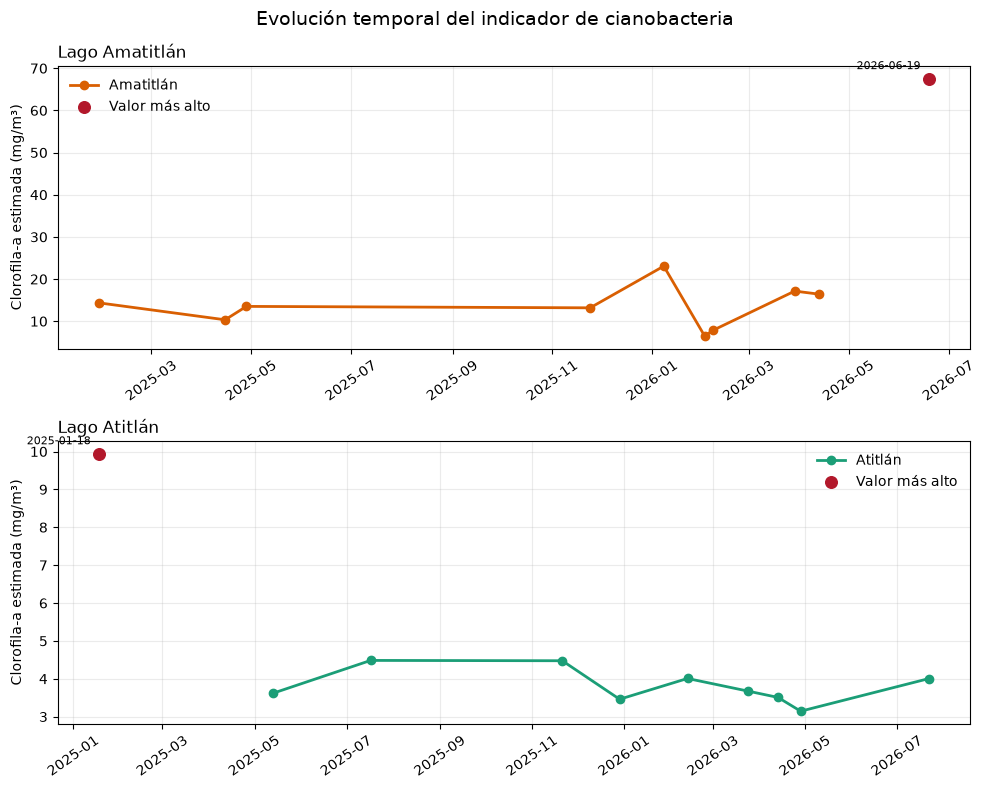

In [10]:
colores = {"Amatitlán": "#d95f02", "Atitlán": "#1b9e77"}
fig, ejes = plt.subplots(2, 1, figsize=(10, 8))

for eje, (lago, datos) in zip(ejes, resumen.groupby("lago", sort=False)):
    datos = datos.sort_values("fecha")
    eje.plot(
        datos["fecha"],
        datos["cianobacteria_promedio"],
        color=colores[lago],
        marker="o",
        linewidth=2,
        label=lago,
    )

    critica = fechas_criticas[fechas_criticas["lago"] == lago].iloc[0]
    eje.scatter(
        critica["fecha"],
        critica["cianobacteria_promedio"],
        color="#b2182b",
        s=70,
        zorder=3,
        label="Valor más alto",
    )
    eje.annotate(
        critica["fecha"].strftime("%Y-%m-%d"),
        (critica["fecha"], critica["cianobacteria_promedio"]),
        xytext=(-6, 7),
        textcoords="offset points",
        ha="right",
        fontsize=8,
    )

    eje.set_title(f"Lago {lago}", loc="left")
    eje.set_ylabel("Clorofila-a estimada (mg/m³)")
    eje.grid(alpha=0.25)
    eje.legend(frameon=False)
    eje.tick_params(axis="x", rotation=35)

fig.suptitle("Evolución temporal del indicador de cianobacteria", fontsize=14)
fig.tight_layout()
fig.savefig(ARCHIVO_FIGURA, dpi=180, bbox_inches="tight")
plt.show()

## Interpretación inicial

En Amatitlán los valores cambian bastante entre fechas. El menor promedio aparece el 2 de febrero de 2026 y el mayor el 19 de junio de 2026, cuando llega a 67.49 mg/m³. Como esa última imagen también tiene la nubosidad más alta de la serie, el resultado se debe revisar con cuidado en el análisis espacial.

Atitlán tiene su valor más alto el 18 de enero de 2025, con 9.93 mg/m³. Desde mayo de 2025 los promedios quedan entre 3.14 y 4.49 mg/m³, por lo que no se observa un aumento continuo durante el período.

La lluvia, la temperatura, la mezcla del agua y la entrada de nutrientes podrían influir en estos cambios. En este avance todavía no se comparan esas variables, así que no se puede asignar una causa solo con las imágenes. El indicador tampoco confirma toxicidad; para eso harían falta mediciones de campo.

# 5. Análisis espacial

Hasta acá solo se trabajó con el promedio de cada imagen. En esta sección se recuperan las rejillas completas (2D) de cada índice para poder ver **dónde dentro de cada lago** se concentra la cianobacteria, y cómo cambia esa distribución entre fechas.

Se reutilizan `buscar_escenas`, `leer_bandas` y `calcular_indices` ya definidas arriba, en vez de descargar el promedio directamente. Cada rejilla se guarda en caché (`.npz`) para no volver a descargarla si se vuelve a correr el notebook.

In [11]:
import folium
from matplotlib import colormaps as cm
from matplotlib.colors import Normalize

CARPETA_RASTERS = CARPETA_PROCESSED / "rasters"
CARPETA_RASTERS.mkdir(parents=True, exist_ok=True)


def obtener_rejillas(lago, fecha, nubosidad, satelite, forzar=False):
    """Devuelve las rejillas 2D (no solo el promedio) de ndvi, ndwi y cianobacteria
    para un lago y fecha, usando caché en disco."""
    ruta_cache = CARPETA_RASTERS / f"{lago}_{fecha}.npz"
    if ruta_cache.exists() and not forzar:
        datos = np.load(ruta_cache)
        return {clave: datos[clave] for clave in datos.files}

    bbox = LAGOS[lago]
    escenas = buscar_escenas(bbox, fecha, nubosidad, satelite)
    bandas = leer_bandas(escenas, bbox)
    indices = calcular_indices(bandas)

    rejillas = {
        "cianobacteria": indices["cianobacteria"].astype("float32"),
        "ndvi": indices["ndvi"].astype("float32"),
        "ndwi": indices["ndwi"].astype("float32"),
        "pixeles_validos": indices["pixeles_validos"],
        "west": np.float64(bbox["west"]), "east": np.float64(bbox["east"]),
        "south": np.float64(bbox["south"]), "north": np.float64(bbox["north"]),
    }
    np.savez_compressed(ruta_cache, **rejillas)
    return rejillas

## 5.1 Selección de fechas y descarga de rejillas

Para comparar, se usa por cada lago la **fecha crítica** (mayor promedio, ya calculada en la sección 4) y la **fecha con el promedio más bajo**. Así se contrastan el mejor y el peor momento observado de cada lago.

In [23]:
fechas_bajas = (
    resumen.dropna(subset=["cianobacteria_promedio"])
    .sort_values("cianobacteria_promedio")
    .groupby("lago", as_index=False)
    .first()
    .sort_values("lago")
)

fechas_a_mapear = pd.concat([fechas_criticas, fechas_bajas]).drop_duplicates(subset=["lago", "fecha"])
fechas_a_mapear[["lago", "fecha", "cianobacteria_promedio"]].round(2)

C:\Users\Emadlg\AppData\Local\Temp\ipykernel_27276\3216898512.py:10: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  fechas_a_mapear[["lago", "fecha", "cianobacteria_promedio"]].round(2)


,lago,fecha,cianobacteria_promedio
0,Amatitlán,2026-06-19,67.49
1,Atitlán,2025-01-18,9.93
0,Amatitlán,2026-02-02,6.49
1,Atitlán,2026-04-28,3.14


In [24]:
rejillas_por_fecha = {}

for _, fila in fechas_a_mapear.iterrows():
    fecha_texto = fila["fecha"].strftime("%Y-%m-%d")
    print(f"Descargando/leyendo caché: {fila['lago']} - {fecha_texto}")
    rejillas_por_fecha[(fila["lago"], fecha_texto)] = obtener_rejillas(
        fila["lago"], fecha_texto, fila["nubosidad_oficial_pct"], fila["satelite"]
    )

print(f"Listo: {len(rejillas_por_fecha)} rejillas disponibles.")

Descargando/leyendo caché: Amatitlán - 2026-06-19
Descargando/leyendo caché: Atitlán - 2025-01-18
Descargando/leyendo caché: Amatitlán - 2026-02-02
Descargando/leyendo caché: Atitlán - 2026-04-28
Listo: 4 rejillas disponibles.


## 5.2 Mapa interactivo del índice de cianobacteria (script de Sentinel Hub reproducido localmente)

Se pinta la rejilla de cianobacteria sobre un mapa de folium. Los píxeles que no son agua o no pasaron el control de calidad quedan transparentes.


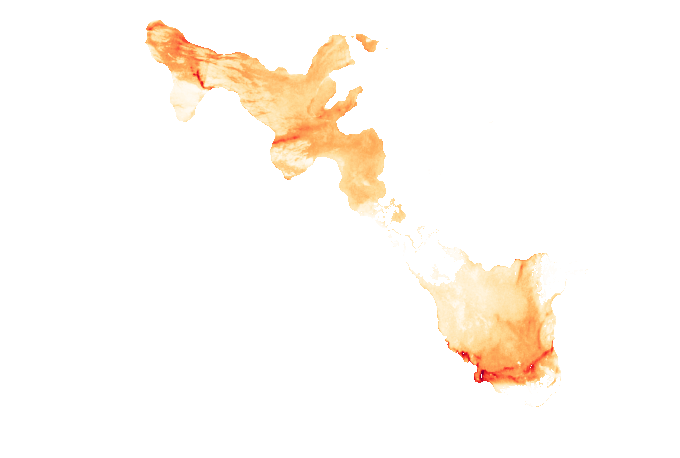

In [25]:
def mapa_indice(
    rejilla,
    campo="cianobacteria",
    vmin=None,
    vmax=None,
    cmap_nombre="YlOrRd"
):
    # Obtener únicamente los píxeles válidos
    valores = np.where(
        rejilla["pixeles_validos"],
        rejilla[campo],
        np.nan
    )

    # Límites de la escala de colores
    vmin = float(np.nanmin(valores)) if vmin is None else float(vmin)
    vmax = float(np.nanmax(valores)) if vmax is None else float(vmax)

    # Mapa de colores
    cmap = cm[cmap_nombre]
    normalizador = Normalize(vmin=vmin, vmax=vmax)

    # Convertir valores a colores RGBA
    rgba = cmap(
        normalizador(
            np.nan_to_num(valores, nan=vmin)
        )
    )

    # Hacer transparentes los píxeles inválidos
    rgba[..., 3] = np.where(
        np.isnan(valores),
        0.0,
        0.85
    )

    # Convertir coordenadas NumPy a float normal de Python
    south = float(rejilla["south"])
    north = float(rejilla["north"])
    west = float(rejilla["west"])
    east = float(rejilla["east"])

    # Centro del mapa
    centro = [
        (south + north) / 2,
        (west + east) / 2
    ]

    # Crear mapa base
    mapa = folium.Map(
        location=centro,
        zoom_start=12,
        tiles="CartoDB positron"
    )

    # Convertir ndarray RGBA a imagen que Folium pueda manejar
    imagen = folium.utilities.image_to_url(rgba)

    # Agregar rejilla al mapa
    folium.raster_layers.ImageOverlay(
        image=imagen,
        bounds=[
            [south, west],
            [north, east]
        ],
        opacity=0.85,
        name=str(campo),
    ).add_to(mapa)

    folium.LayerControl().add_to(mapa)

    return mapa


# Ejemplo con el lago de Amatitlán
lago_ejemplo = "Amatitlán"

fecha_ejemplo = fechas_criticas.loc[
    fechas_criticas.lago == lago_ejemplo,
    "fecha"
].dt.strftime("%Y-%m-%d").iloc[0]

mapa_indice(
    rejillas_por_fecha[(lago_ejemplo, fecha_ejemplo)]
)

Amatitlán
Fecha crítica (mayor promedio): 2026-06-19



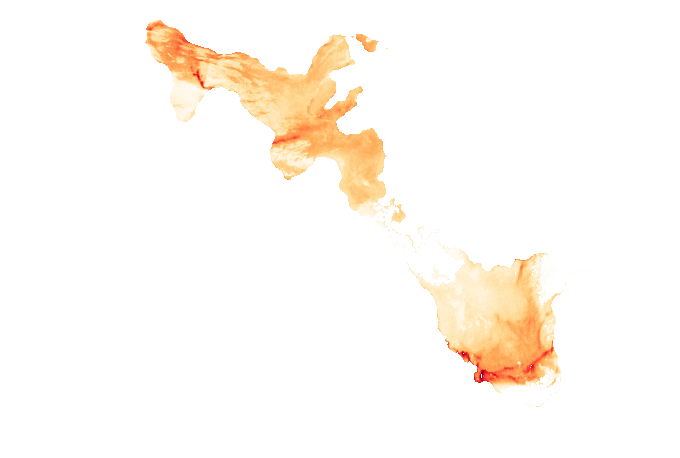

Amatitlán
Fecha con menor promedio: 2026-02-02



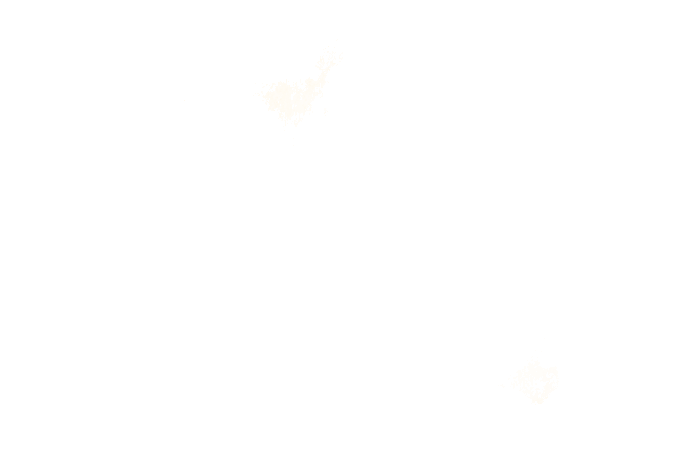

Atitlán
Fecha crítica (mayor promedio): 2025-01-18



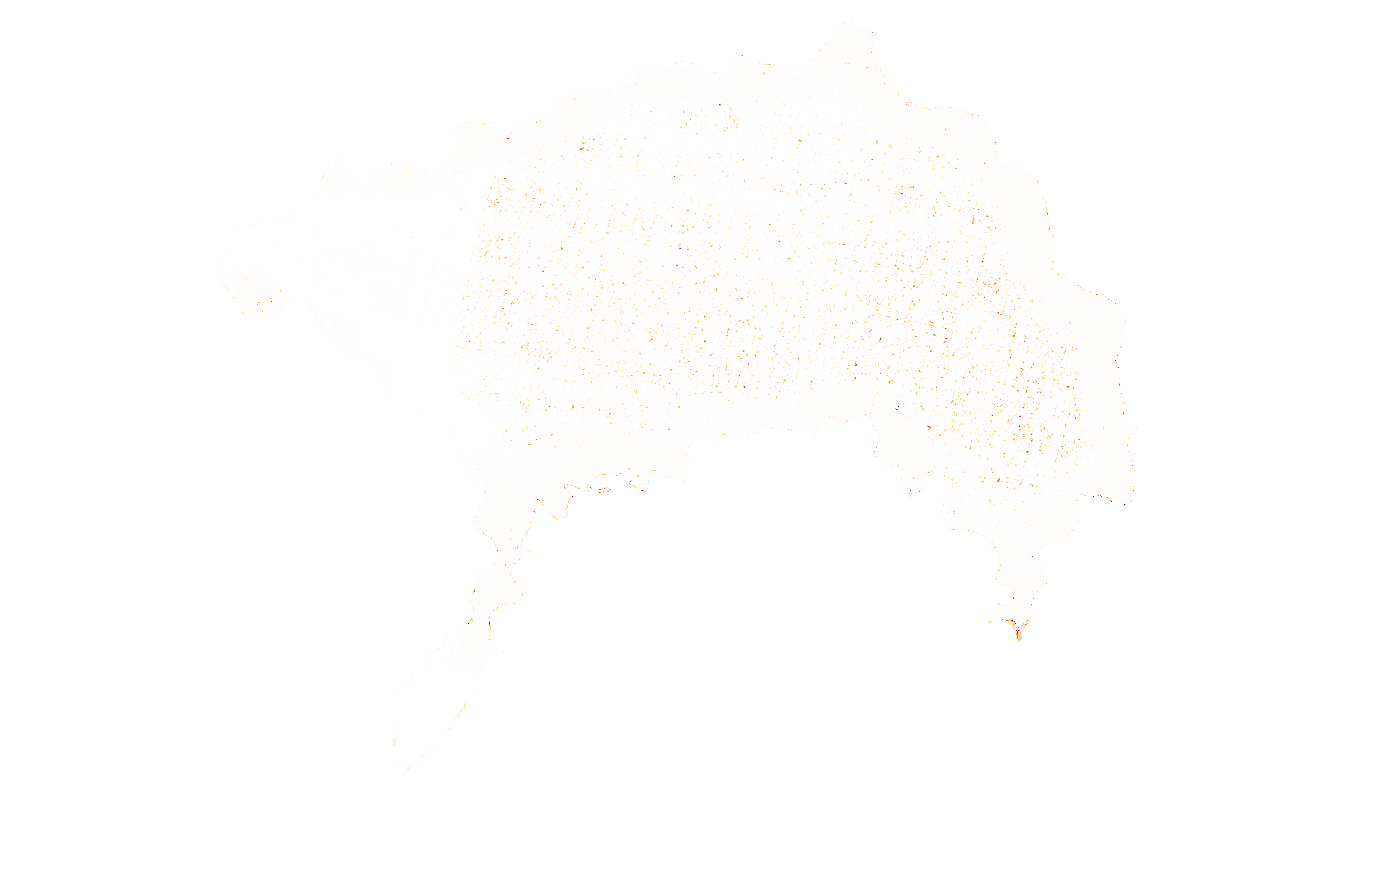

Atitlán
Fecha con menor promedio: 2026-04-28



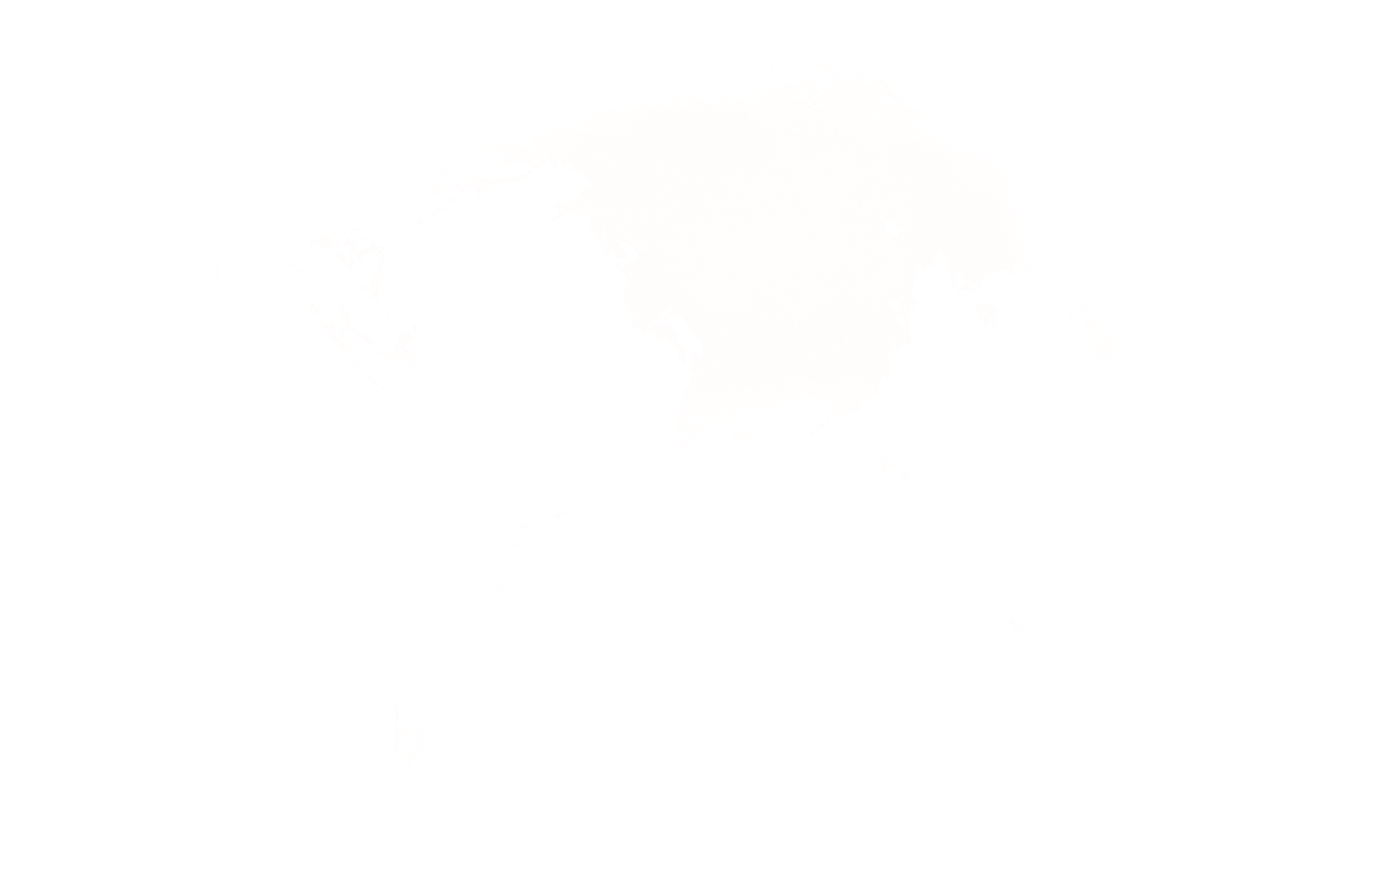

In [26]:

fechas_comparacion = {
    "Amatitlán": {
        "critica": "2026-06-19",
        "baja": "2026-02-02"
    },
    "Atitlán": {
        "critica": "2025-01-18",
        "baja": "2026-04-28"
    }
}

# Generar comparación para cada lago
for lago, fechas in fechas_comparacion.items():

    fecha_critica = fechas["critica"]
    fecha_baja = fechas["baja"]

    rejilla_critica = rejillas_por_fecha[
        (lago, fecha_critica)
    ]

    rejilla_baja = rejillas_por_fecha[
        (lago, fecha_baja)
    ]

    # --------------------------------------------------------
    # Escala de colores común para las dos fechas del lago
    # --------------------------------------------------------

    valores_critica = rejilla_critica["cianobacteria"][
        rejilla_critica["pixeles_validos"]
    ]

    valores_baja = rejilla_baja["cianobacteria"][
        rejilla_baja["pixeles_validos"]
    ]

    valores_combinados = np.concatenate([
        valores_critica,
        valores_baja
    ])

    vmin = float(np.nanmin(valores_combinados))
    vmax = float(np.nanmax(valores_combinados))

    # --------------------------------------------------------
    # Mostrar fecha crítica
    # --------------------------------------------------------

    print("=" * 60)
    print(f"{lago}")
    print(f"Fecha crítica (mayor promedio): {fecha_critica}")
    print("=" * 60)

    display(
        mapa_indice(
            rejilla_critica,
            campo="cianobacteria",
            vmin=vmin,
            vmax=vmax,
            cmap_nombre="YlOrRd"
        )
    )

    # --------------------------------------------------------
    # Mostrar fecha con menor promedio
    # --------------------------------------------------------

    print(f"{lago}")
    print(f"Fecha con menor promedio: {fecha_baja}")

    display(
        mapa_indice(
            rejilla_baja,
            campo="cianobacteria",
            vmin=vmin,
            vmax=vmax,
            cmap_nombre="YlOrRd"
        )
    )

## 5.3 Mapas comparativos entre fechas (fecha crítica vs. fecha con menor promedio)

Se comparan, lado a lado, la fecha con mayor y menor promedio de cada lago.

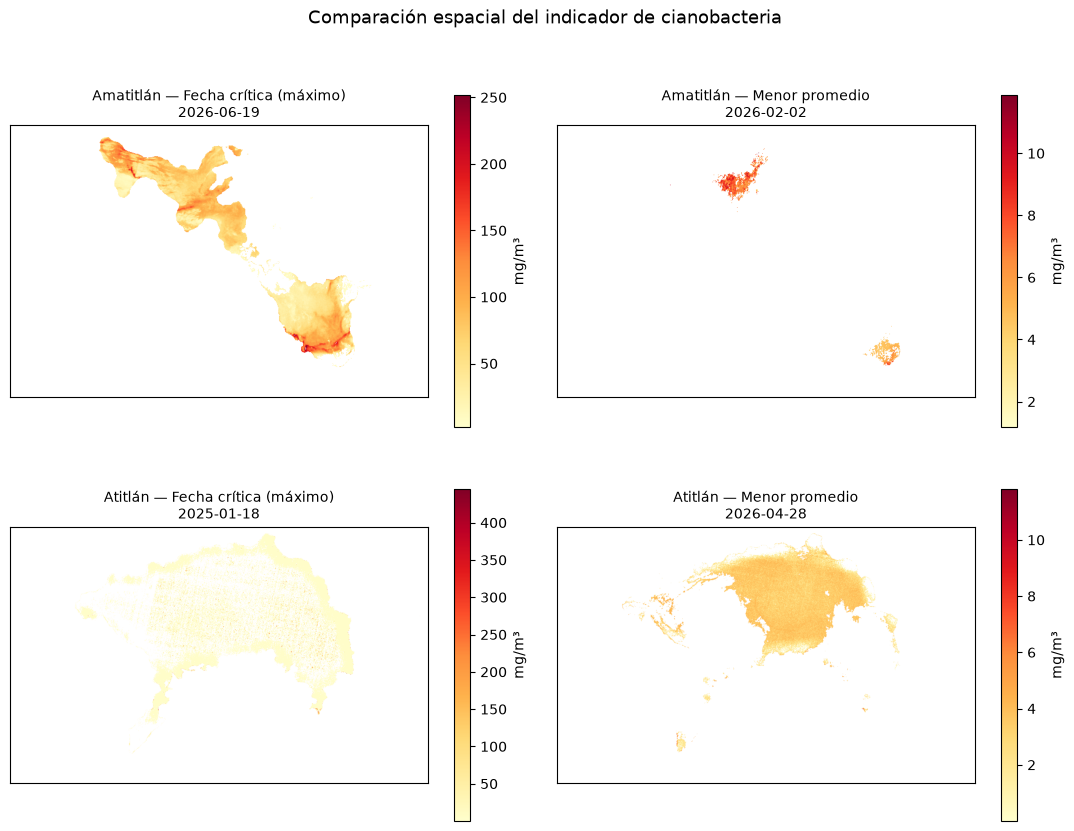

In [27]:
fig, ejes = plt.subplots(2, 2, figsize=(11, 9))

for fila_idx, lago in enumerate(["Amatitlán", "Atitlán"]):
    for col_idx, (etiqueta, tabla) in enumerate([("Fecha crítica (máximo)", fechas_criticas), ("Menor promedio", fechas_bajas)]):
        fecha_texto = tabla.loc[tabla.lago == lago, "fecha"].dt.strftime("%Y-%m-%d").iloc[0]
        rejilla = rejillas_por_fecha[(lago, fecha_texto)]
        valores = np.where(rejilla["pixeles_validos"], rejilla["cianobacteria"], np.nan)

        eje = ejes[fila_idx, col_idx]
        im = eje.imshow(
            valores, cmap="YlOrRd", origin="upper",
            extent=[rejilla["west"], rejilla["east"], rejilla["south"], rejilla["north"]],
        )
        eje.set_title(f"{lago} — {etiqueta}\n{fecha_texto}", fontsize=10)
        eje.set_xticks([]); eje.set_yticks([])
        fig.colorbar(im, ax=eje, label="mg/m³", shrink=0.75)

fig.suptitle("Comparación espacial del indicador de cianobacteria", fontsize=13)
fig.tight_layout()
fig.savefig(CARPETA_FIGURES / "comparacion_espacial.png", dpi=180, bbox_inches="tight")
plt.show()

## 5.4 Interpretación espacial

Los mapas muestran que la cianobacteria no se distribuye de forma pareja en los lagos; hay zonas con valores más altos que otras.

En Amatitlán, el 19 de junio de 2026 se ven valores altos en varias partes, pero la mayor concentración aparece en un extremo del lago. En cambio, el 2 de febrero de 2026 los valores fueron mucho más bajos y solo hay datos en algunas áreas. Además, el mapa de junio tiene huecos por nubosidad, así que hay que interpretarlo con cuidado. En Atitlán, el 18 de enero de 2025 las concentraciones son mucho mayores que el 28 de abril de 2026. A diferencia de Amatitlán, los valores altos parecen estar más repartidos por todo el lago.

En general, la concentración varía según la zona y la fecha. Amatitlán tiene un punto muy alto en su fecha crítica, mientras que en Atitlán el aumento se ve más extendido. Con estos mapas no se puede saber si las concentraciones están relacionadas con ríos, zonas urbanas o áreas poco profundas, porque esa información no aparece en las imágenes.



# 6. Correlación entre NDVI, NDWI y la cianobacteria

Se usa el promedio por lago y fecha ya calculado en `resumen` (columnas `ndvi_promedio`, `ndwi_promedio`, `cianobacteria_promedio`). Se revisa la correlación de Pearson en conjunto y por separado para cada lago, porque cada uno puede tener una relación distinta.

In [16]:
valido = resumen.dropna(subset=["cianobacteria_promedio"]).copy()

correlaciones = {"General": {
    "ciano_vs_ndvi": valido["cianobacteria_promedio"].corr(valido["ndvi_promedio"]),
    "ciano_vs_ndwi": valido["cianobacteria_promedio"].corr(valido["ndwi_promedio"]),
}}
for lago, grupo in valido.groupby("lago"):
    correlaciones[lago] = {
        "ciano_vs_ndvi": grupo["cianobacteria_promedio"].corr(grupo["ndvi_promedio"]),
        "ciano_vs_ndwi": grupo["cianobacteria_promedio"].corr(grupo["ndwi_promedio"]),
    }

pd.DataFrame(correlaciones).T.round(3)

,ciano_vs_ndvi,ciano_vs_ndwi
General,-0.093,-0.097
Amatitlán,0.222,0.317
Atitlán,0.918,0.786


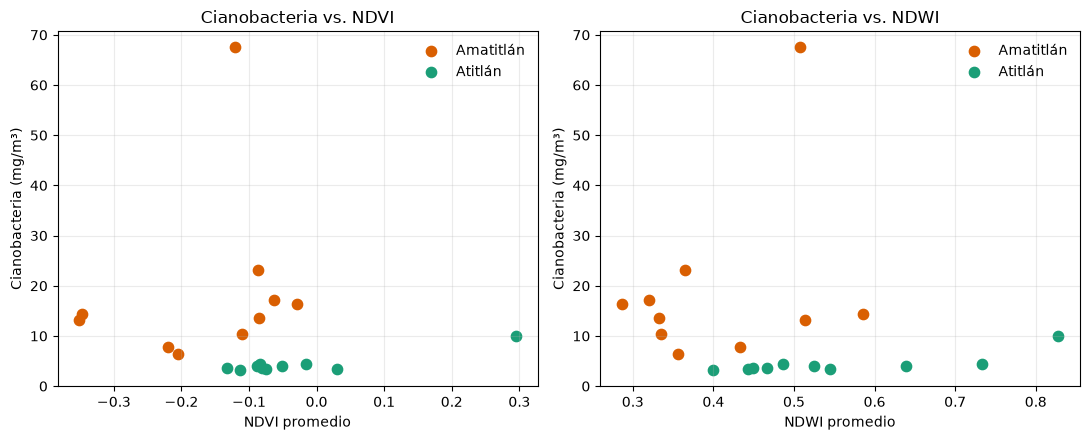

In [17]:
colores = {"Amatitlán": "#d95f02", "Atitlán": "#1b9e77"}

fig, ejes = plt.subplots(1, 2, figsize=(11, 4.5))
for lago, grupo in valido.groupby("lago"):
    ejes[0].scatter(grupo["ndvi_promedio"], grupo["cianobacteria_promedio"], color=colores[lago], label=lago, s=55)
    ejes[1].scatter(grupo["ndwi_promedio"], grupo["cianobacteria_promedio"], color=colores[lago], label=lago, s=55)

ejes[0].set_xlabel("NDVI promedio"); ejes[0].set_ylabel("Cianobacteria (mg/m³)")
ejes[1].set_xlabel("NDWI promedio"); ejes[1].set_ylabel("Cianobacteria (mg/m³)")
ejes[0].set_title("Cianobacteria vs. NDVI"); ejes[1].set_title("Cianobacteria vs. NDWI")
for eje in ejes:
    eje.grid(alpha=0.25); eje.legend(frameon=False)

fig.tight_layout()
fig.savefig(CARPETA_FIGURES / "correlacion_indices.png", dpi=180, bbox_inches="tight")
plt.show()


## 6.1 Hallazgos

Con los 20 pares lago-fecha que sí tenían escena disponible, la correlación general (mezclando ambos lagos) entre cianobacteria y NDVI o NDWI resultó **débil y prácticamente nula** (r ≈ -0.09 con NDVI, r ≈ -0.10 con NDWI). Esto no quiere decir que no haya una relación real; más bien, **mezclar ambos lagos oculta el patrón**, porque Amatitlán y Atitlán tienen rangos de cianobacteria muy distintos (Amatitlán alcanza valores mucho más altos) y eso domina la dispersión general.

Al calcular la correlación por separado, el patrón se vuelve mucho más claro:

- **Atitlán**: la correlación es **positiva y fuerte** tanto con NDVI (r ≈ 0.92) como con NDWI (r ≈ 0.79). Es decir, en las fechas donde sube el promedio de cianobacteria, también suben el NDVI (más señal de tipo vegetal o pigmento fotosintético) y el NDWI (más contenido de agua o menos reflectancia en el infrarrojo cercano, lo que es coherente con una superficie con más biomasa flotando). Esto tiene sentido ambientalmente: una floración de cianobacteria añade pigmento fotosintético y cambia la reflectancia del agua de forma parecida a como lo hace la vegetación.
- **Amatitlán**: la correlación es **positiva pero débil** (r ≈ 0.22 con NDVI, r ≈ 0.32 con NDWI). El lago tiene niveles de cianobacteria altos casi todo el año (mediana de 13.9 mg/m³, ver sección 7), así que el NDVI y el NDWI no varían tanto de una fecha a otra en comparación con la cianobacteria. Además, la fecha con el valor más alto (19 de junio de 2026) también es la de mayor nubosidad, lo que puede añadir ruido en ese punto.

En conjunto, el hallazgo principal es que **la relación entre estos índices y la cianobacteria depende del contexto del lago**. En un lago con aguas más transparentes y niveles variables como Atitlán, NDVI y NDWI son buenos indicadores indirectos de floración. En un lago ya crónicamente eutrófico como Amatitlán, la señal de fondo es alta y constante, así que estos índices explican menos de la variación observada.

# 7. Análisis y comparación entre lagos

In [18]:
comparacion = valido.groupby("lago")["cianobacteria_promedio"].agg(
    n_fechas="count", promedio="mean", mediana="median", desv_estandar="std", minimo="min", maximo="max"
).round(2)
comparacion["coef_variacion"] = (comparacion["desv_estandar"] / comparacion["promedio"]).round(2)

for umbral in (10, 15, 20):
    comparacion[f"pct_fechas_mayor_{umbral}"] = valido.groupby("lago")["cianobacteria_promedio"].apply(
        lambda serie, u=umbral: round(100 * (serie > u).mean(), 1)
    )

comparacion

,n_fechas,promedio,mediana,desv_estandar,minimo,maximo,coef_variacion,pct_fechas_mayor_10,pct_fechas_mayor_15,pct_fechas_mayor_20
lago,,,,,,,,,,
Amatitlán,10,18.98,13.94,17.70,6.49,67.49,0.93,80.0,40.0,20.0
Atitlán,10,4.43,3.84,1.98,3.14,9.93,0.45,0.0,0.0,0.0


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
datos_box = [valido.loc[valido.lago == l, "cianobacteria_promedio"].values for l in ["Amatitlán", "Atitlán"]]
caja = ax.boxplot(datos_box, tick_labels=["Amatitlán", "Atitlán"], patch_artist=True)
for parche, lago in zip(caja["boxes"], ["Amatitlán", "Atitlán"]):
    parche.set_facecolor(colores[lago]); parche.set_alpha(0.5)
ax.set_ylabel("Cianobacteria promedio por fecha (mg/m³)")
ax.grid(alpha=0.25, axis="y")
fig.tight_layout()
fig.savefig(CARPETA_FIGURES / "boxplot_lagos.png", dpi=180, bbox_inches="tight")
plt.show()

## 7.1–7.2 Intensidad y frecuencia de la proliferación

Durante el período estudiado, Amatitlán presenta un promedio de cianobacteria (18.98 mg/m³) más de **cuatro veces mayor** que Atitlán (4.43 mg/m³), y su mediana (13.94 mg/m³) también es unas 3.6 veces más alta (3.84 mg/m³ en Atitlán). Además, Amatitlán es mucho más variable: su coeficiente de variación es 0.93 frente a 0.45 en Atitlán, lo que significa que sus niveles fluctúan aproximadamente el doble.

En cuanto a la frecuencia, el 80% de las fechas analizadas en Amatitlán superaron los 10 mg/m³, y un 20% superaron los 20 mg/m³ (incluyendo el pico de 67.49 mg/m³ del 19 de junio de 2026). En Atitlán, **ninguna** de las 10 fechas con datos válidos superó los 10 mg/m³; la serie se mantiene siempre en un rango bajo y relativamente estable (entre 3.1 y 9.9 mg/m³).

En resumen: Amatitlán no solo tiene niveles más altos en promedio, sino que su proliferación es más intensa (picos más altos) y más frecuente (más fechas por encima de cualquier umbral razonable) que la de Atitlán, cuyo comportamiento es comparativamente estable durante el año y medio analizado.



## 7.3 Posibles diferencias en las causas

Ambos lagos son de origen volcánico y no tienen salida superficial de agua, lo que limita su capacidad de renovación y hace que los nutrientes que entran tiendan a acumularse. Sin embargo, hay diferencias importantes entre ellos que ayudan a explicar por qué Amatitlán muestra una proliferación mucho más intensa y persistente:

- **Presión urbana y aguas residuales.** Amatitlán está en el área metropolitana de la Ciudad de Guatemala y recibe las descargas del río Villalobos y otros afluentes que atraviesan zonas densamente pobladas. Estudios y reportes ambientales lo describen como un lago en estado eutrófico desde hace décadas, cercano incluso al límite hipereutrófico. Atitlán tiene población alrededor de su cuenca, pero mucho menos concentrada y con menor infraestructura industrial. La contaminación allí proviene sobre todo de aguas residuales domésticas con tratamiento insuficiente y de escurrimientos agrícolas, pero en un volumen bastante menor en relación con el tamaño del lago.

- **Geografía y volumen de dilución.** Atitlán es mucho más grande y profundo (hasta unos 320 m de profundidad, con un espejo de agua de más de 100 km²) que Amatitlán, que es pequeño y somero. Un volumen de agua mucho mayor diluye más los nutrientes que entran, lo que ayuda a explicar por qué Atitlán mantiene niveles bajos y estables la mayor parte del tiempo.

- **Temperatura y altitud.** Amatitlán está a menor altitud (~1,189 msnm) que Atitlán (~1,562 msnm), lo que se traduce en temperaturas del agua más cálidas casi todo el año, una condición que favorece el crecimiento de cianobacterias.

- **Eventos puntuales asociados a lluvias.** En Atitlán, los episodios de floración documentados (por ejemplo, en 2009 y 2015) se han relacionado con tormentas fuertes que arrastran nutrientes desde la cuenca hacia el lago, más que con una contaminación crónica constante. Esto es consistente con lo observado en los datos: Atitlán se mantiene bajo y estable casi todo el período, sin un pico tan marcado como el de Amatitlán.

En conjunto, la diferencia entre ambos lagos parece explicarse menos por el clima general de Guatemala (al que ambos están expuestos) y más por la combinación de presión urbana, volumen de dilución y temperatura del agua, factores en los que Amatitlán está en clara desventaja frente a Atitlán.

# 8. Análisis exploratorio adicional

## 8.1–8.2 Extensión espacial de la floración y zonas persistentes

Para esto se necesita trabajar a nivel de píxel (no solo el promedio), usando las rejillas obtenidas en la sección 5. Se define un umbral simple (por ejemplo, el percentil 75 de todos los valores válidos de cada lago) para clasificar un píxel como "valor alto", y se calcula qué porcentaje del lago lo supera en cada fecha mapeada.

In [28]:

resultados_extension = []

for lago in ["Amatitlán", "Atitlán"]:

    # Obtener todos los píxeles válidos disponibles para el lago
    valores_lago = []

    for (nombre_lago, fecha), rejilla in rejillas_por_fecha.items():
        if nombre_lago == lago:
            valores = rejilla["cianobacteria"][
                rejilla["pixeles_validos"]
            ]
            valores = valores[np.isfinite(valores)]
            valores_lago.extend(valores)

    valores_lago = np.asarray(valores_lago)

    # Percentil 75 de los valores espaciales del lago
    umbral_lago = np.nanpercentile(valores_lago, 75)

    # Calcular porcentaje de área con valores altos por fecha
    for (nombre_lago, fecha), rejilla in rejillas_por_fecha.items():

        if nombre_lago != lago:
            continue

        valores = rejilla["cianobacteria"][
            rejilla["pixeles_validos"]
        ]
        valores = valores[np.isfinite(valores)]

        if valores.size == 0:
            continue

        pct_alto = 100 * np.mean(valores > umbral_lago)

        resultados_extension.append({
            "lago": lago,
            "fecha": fecha,
            "umbral_p75_mg_m3": round(float(umbral_lago), 2),
            "pct_lago_con_valores_altos": round(float(pct_alto), 1)
        })


extension_espacial = (
    pd.DataFrame(resultados_extension)
    .sort_values(["lago", "fecha"])
    .reset_index(drop=True)
)

extension_espacial

,lago,fecha,umbral_p75_mg_m3,pct_lago_con_valores_altos
0,Amatitlán,2026-02-02,86.04,0.0
1,Amatitlán,2026-06-19,86.04,27.1
2,Atitlán,2025-01-18,4.07,22.5
3,Atitlán,2026-04-28,4.07,4.7


Para identificar **zonas persistentes de acumulación**, se compara, píxel por píxel, si el valor está por encima del umbral tanto en la fecha crítica como en la fecha de menor promedio de cada lago. Los píxeles que aparecen altos en ambas fechas son candidatos a zona persistente (no solo un pico puntual). Esto requiere que ambas rejillas tengan el mismo tamaño; si no lo tienen (por ejemplo, por recortes distintos de escena), hay que alinear/recortar antes de comparar.

In [29]:

def zonas_persistentes(lago):

    fecha_alta = (
        fechas_criticas.loc[
            fechas_criticas.lago == lago,
            "fecha"
        ]
        .dt.strftime("%Y-%m-%d")
        .iloc[0]
    )

    fecha_baja = (
        fechas_bajas.loc[
            fechas_bajas.lago == lago,
            "fecha"
        ]
        .dt.strftime("%Y-%m-%d")
        .iloc[0]
    )

    r_alta = rejillas_por_fecha[(lago, fecha_alta)]
    r_baja = rejillas_por_fecha[(lago, fecha_baja)]

    # Verificar que ambas rejillas sean comparables
    if r_alta["cianobacteria"].shape != r_baja["cianobacteria"].shape:
        print(
            f"{lago}: las rejillas tienen tamaños diferentes "
            f"{r_alta['cianobacteria'].shape} vs "
            f"{r_baja['cianobacteria'].shape}"
        )
        return None

    # Obtener todos los valores válidos de ambas fechas
    valores = np.concatenate([
        r_alta["cianobacteria"][r_alta["pixeles_validos"]],
        r_baja["cianobacteria"][r_baja["pixeles_validos"]]
    ])

    valores = valores[np.isfinite(valores)]

    # Umbral de valores altos
    umbral = np.nanpercentile(valores, 75)

    # Píxeles altos en ambas fechas
    persistentes = (
        (r_alta["cianobacteria"] > umbral)
        & r_alta["pixeles_validos"]
        & (r_baja["cianobacteria"] > umbral)
        & r_baja["pixeles_validos"]
    )

    validos_ambos = (
        r_alta["pixeles_validos"]
        & r_baja["pixeles_validos"]
    )

    porcentaje = (
        100 * persistentes.sum() / validos_ambos.sum()
        if validos_ambos.sum() > 0
        else 0
    )

    print(f"\n{lago}")
    print(f"Fecha crítica: {fecha_alta}")
    print(f"Fecha baja: {fecha_baja}")
    print(f"Umbral P75: {umbral:.2f} mg/m³")
    print(f"Píxeles persistentes: {persistentes.sum()}")
    print(
        f"Área persistente aproximada: "
        f"{porcentaje:.2f}% del área válida comparada"
    )

    # Visualización
    plt.figure(figsize=(8, 6))

    plt.imshow(
        persistentes,
        cmap="YlOrRd",
        interpolation="nearest"
    )

    plt.title(
        f"Zonas persistentes de cianobacteria\n"
        f"{lago}: {fecha_alta} vs {fecha_baja}"
    )

    plt.xlabel("Píxel X")
    plt.ylabel("Píxel Y")
    plt.colorbar(
        label="Zona persistente (1 = sí, 0 = no)"
    )

    plt.show()

    return persistentes


Amatitlán
Fecha crítica: 2026-06-19
Fecha baja: 2026-02-02
Umbral P75: 86.04 mg/m³
Píxeles persistentes: 0
Área persistente aproximada: 0.00% del área válida comparada


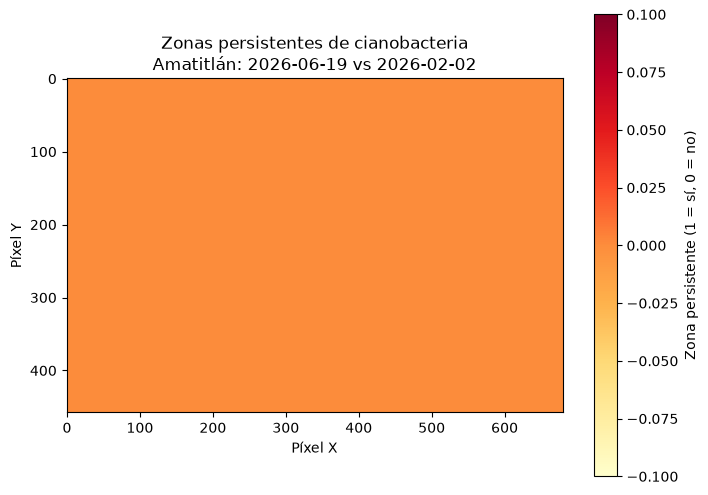


Atitlán
Fecha crítica: 2025-01-18
Fecha baja: 2026-04-28
Umbral P75: 4.07 mg/m³
Píxeles persistentes: 758
Área persistente aproximada: 0.58% del área válida comparada


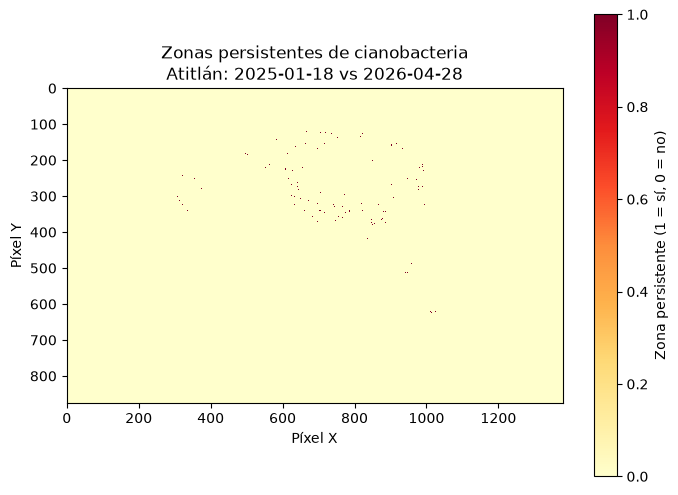

In [30]:
persistentes_amatitlan = zonas_persistentes("Amatitlán")
persistentes_atitlan = zonas_persistentes("Atitlán")

## 8.3 Distribución de valores entre fechas (histogramas y boxplot)

A nivel de píxel: histogramas de la cianobacteria dentro de cada rejilla descargada, para ver qué tan concentrada o dispersa está la distribución en cada fecha.

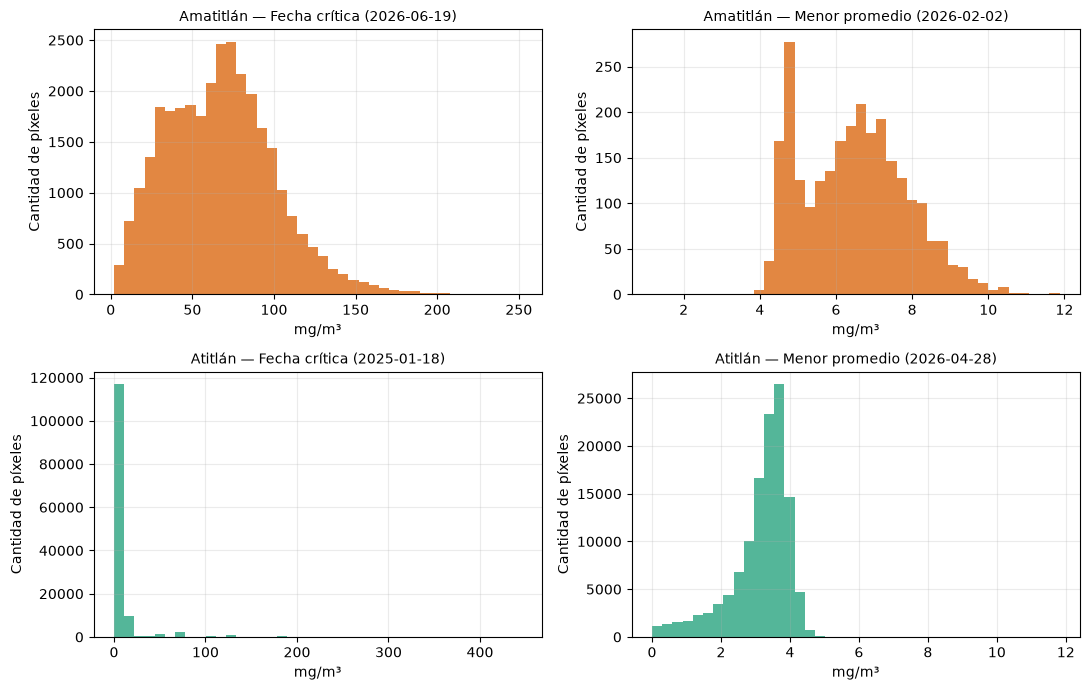

In [21]:
fig, ejes = plt.subplots(2, 2, figsize=(11, 7), sharex=False)
for fila_idx, lago in enumerate(["Amatitlán", "Atitlán"]):
    for col_idx, (etiqueta, tabla) in enumerate([("Fecha crítica", fechas_criticas), ("Menor promedio", fechas_bajas)]):
        fecha_texto = tabla.loc[tabla.lago == lago, "fecha"].dt.strftime("%Y-%m-%d").iloc[0]
        rejilla = rejillas_por_fecha[(lago, fecha_texto)]
        valores = rejilla["cianobacteria"][rejilla["pixeles_validos"]]
        valores = valores[np.isfinite(valores)]

        eje = ejes[fila_idx, col_idx]
        eje.hist(valores, bins=40, color=colores[lago], alpha=0.75)
        eje.set_title(f"{lago} — {etiqueta} ({fecha_texto})", fontsize=10)
        eje.set_xlabel("mg/m³"); eje.set_ylabel("Cantidad de píxeles")
        eje.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(CARPETA_FIGURES / "histogramas_pixeles.png", dpi=180, bbox_inches="tight")
plt.show()

A nivel de fecha (usando el promedio de cada imagen, ya calculado en `resumen`), el boxplot de la sección 7 ya muestra que Amatitlán tiene una distribución mucho más ancha y con más valores extremos que Atitlán, cuya caja es angosta y con pocos valores atípicos.

## 8.4 Patrón estacional

Se agrupa el promedio de cianobacteria por mes del año (mezclando ambos años del período, ya que solo hay ~1.5 años de datos y no alcanza para separar por año).

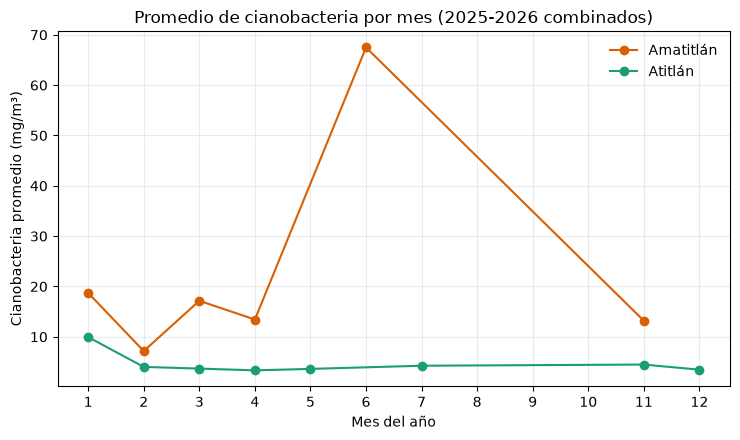

In [22]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for lago, grupo in valido.groupby("lago"):
    mensual = grupo.groupby(grupo["fecha"].dt.month)["cianobacteria_promedio"].mean()
    ax.plot(mensual.index, mensual.values, marker="o", color=colores[lago], label=lago)

ax.set_xlabel("Mes del año"); ax.set_ylabel("Cianobacteria promedio (mg/m³)")
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.25); ax.legend(frameon=False)
ax.set_title("Promedio de cianobacteria por mes (2025-2026 combinados)")
fig.tight_layout()
fig.savefig(CARPETA_FIGURES / "estacionalidad.png", dpi=180, bbox_inches="tight")
plt.show()

## 8.5 Interpretación general del análisis exploratorio

Con las fechas disponibles no se observa un patrón estacional claro. Amatitlán presenta concentraciones de cianobacteria más altas y variables que Atitlán, aunque la cantidad de fechas analizadas no permite obtener conclusiones definitivas.

En la fecha crítica, los valores altos cubrieron aproximadamente el 27.1 % de Amatitlán y el 22.5 % de Atitlán. En las fechas de menor promedio estos valores disminuyeron a 0 % y 4.7 %, respectivamente. Además, Amatitlán no presentó zonas persistentes, mientras que en Atitlán estas representaron aproximadamente el 0.58 % del área comparada. En general, los resultados muestran que la concentración de cianobacteria cambia tanto con el tiempo como entre ambos lagos.

# Conclusiones generales

- Se estableció conexión con la API de Sentinel-2 (openEO, Copernicus Data Space) y se obtuvieron únicamente las bandas necesarias para cada lago y fecha, sin descargar escenas completas, utilizando el catálogo público STAC de Earth Search como fuente de lectura.
- Se calcularon NDVI, NDWI y un indicador de cianobacteria (clorofila-a mediante NDCI y script CyanoLakes) para 20 de las 22 combinaciones oficiales de lago y fecha; las dos combinaciones sin escena disponible se mantuvieron como datos faltantes.
- **Amatitlán** presentó niveles de cianobacteria consistentemente más altos, más variables (coef. de variación 0.93) y más frecuentes por encima de distintos umbrales que **Atitlán** (coef. de variación 0.45), con un pico marcado el 19 de junio de 2026 (67.49 mg/m³).
- La correlación entre NDVI/NDWI y la cianobacteria es positiva y fuerte en Atitlán (r ≈ 0.9 y 0.8) pero débil en Amatitlán (r ≈ 0.2–0.3), lo que sugiere que estos índices funcionan mejor como indicador indirecto de floración en lagos con condiciones de base más estables y transparentes.
- Las diferencias entre lagos son consistentes con lo reportado en la literatura sobre ambos cuerpos de agua: Amatitlán tiene una carga de aguas residuales urbanas mucho mayor, es más pequeño y somero, y se encuentra a menor altitud (agua más cálida) que Atitlán, factores que en conjunto favorecen una eutrofización más severa y persistente.
- El análisis espacial (mapas, extensión de la floración, zonas persistentes) requiere ejecutar las celdas de la sección 5 y 8.1–8.2 con acceso real a las imágenes; los resultados y su interpretación final deben completarse después de correr esas celdas.
- Como se mencionó en el avance, estos resultados constituyen una **señal para orientar el monitoreo**, no una confirmación de toxicidad. Para ello se requieren mediciones directas en campo.
